/Users/setthakorntanom/miniconda3/envs/py312/lib/python3.12/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(in

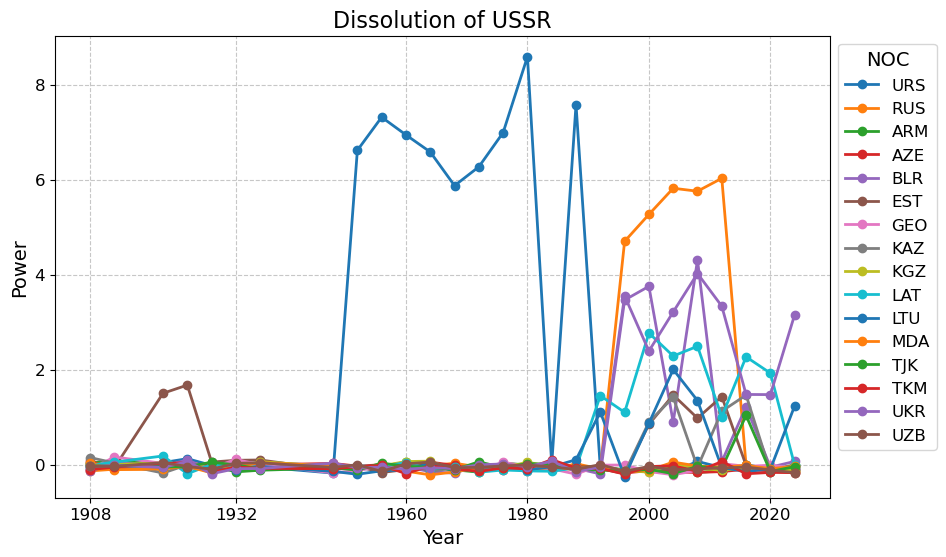

In [119]:
import pyro
from matplotlib import pyplot as plt
import math
import numpy as np


pyro.clear_param_store()
pyro.get_param_store().load("trained_model_params_long.pth")

italy_power_mean = []
china_power_mean = []

italy_ce_mean = []
china_ce_mean = []

name_dict = {"URS": 218,"RUS": 175, "ARM": 10, "AZE": 15, "BLR": 26, "EST": 66, "GEO": 79, "KAZ": 107, "KGZ": 109, "LAT": 16, "LTU": 124, "MDA": 131, "TJK": 204, "TKM": 205, "UKR":216, "UZB":221}
soviet_dict = {"URS": [],"RUS": [], "ARM": [], "AZE": [], "BLR": [], "EST": [], "GEO": [], "KAZ": [], "KGZ": [], "LAT": [], "LTU": [], "MDA": [], "TJK": [], "TKM": [], "UKR":[], "UZB":[]}
year_arr = list(range(1908, 2025, 4))
year_arr.remove(1916)
year_arr.remove(1940)
year_arr.remove(1944)
for i in range(4, 31):
    P_loc_param = pyro.get_param_store()[f"P_loc_{i}"]
    P_loc_param = P_loc_param.detach().numpy()
    P_scale_param = pyro.get_param_store()[f"P_scale_{i}"]
    P_scale_param = P_scale_param.detach().numpy()
    P_loc_param_athletics = P_loc_param[:, 8]
    P_scale_param_athletics = P_scale_param[:, 8]

    for noc, i_noc in name_dict.items():
        soviet_dict[noc].append(P_loc_param_athletics[i_noc])

fig, ax = plt.subplots(figsize=(10, 6))  # Adjust the figure size for better readability

# Loop through the dictionary and plot each line
for noc, power in soviet_dict.items():
    ax.plot(year_arr, power, label=noc, marker='o', linestyle='-', linewidth=2)

# Add a title and labels for clarity
ax.set_title("Dissolution of USSR", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Power", fontsize=14)

# Customize the legend with a better location and style
ax.legend(title="NOC", loc='upper left', bbox_to_anchor=(1, 1), fontsize=12, title_fontsize=14)

# Add a grid to the plot for easier interpretation
ax.grid(True, linestyle='--', alpha=0.7)

# Improve the x-axis ticks for better readability
ax.set_xticks(year_arr[::5])  # Show every 5th year if year_arr has many values
ax.tick_params(axis='both', labelsize=12)

In [ ]:
import pandas as pd
import torch
df = pd.read_csv("summerOly_athletes_team_id_no_high_irregulars_numerical_experience_combined_reassigned_home.csv")
num_unique_times = 31
num_countries = 234
#num_sports = 76

#medal_tensor = torch.zeros((num_unique_times, num_countries, 4))
medal_tensor = torch.zeros(5, 4)
home_tensor = torch.zeros((num_unique_times, num_countries, 2))
#theta_tensor = torch.zeros((num_unique_times, num_countries, num_sports, 2))

for row in df.iterrows():
    year = row[1]["Year"]
    country = row[1]["NOC"]
    #sport = row[1]["Sport"]
    medal = row[1]["Medal"]
    home = row[1]["Home_Country"]
    experience = int(min(row[1]["Experience"],4))
    experience_std = row[1]["Experience_std"]

    if medal == "Gold":
        medal_tensor[experience][0] += 1
    elif medal == "Silver":
        medal_tensor[experience][1] += 1
    elif medal == "Bronze":
        medal_tensor[experience][2] += 1
    else:
        medal_tensor[experience][3] += 1
    
    
    if home == 1:
        pass
        #theta_tensor[year][country][sport][1] = 1

# divide medal_tensor by the sum of each row
medal_tensor /= medal_tensor.sum(1)[:,None]
medal_tensor = medal_tensor[:,:-1]*100
print(medal_tensor)
# plot side-by-side bar chart of medal_tensor where x-value are the index of each row



tensor([[3.1235, 3.2005, 3.5762],
        [4.5402, 4.3573, 4.5464],
        [4.8329, 4.5564, 5.0854],
        [5.0380, 3.9449, 4.8479],
        [4.8507, 4.7264, 3.9801]])


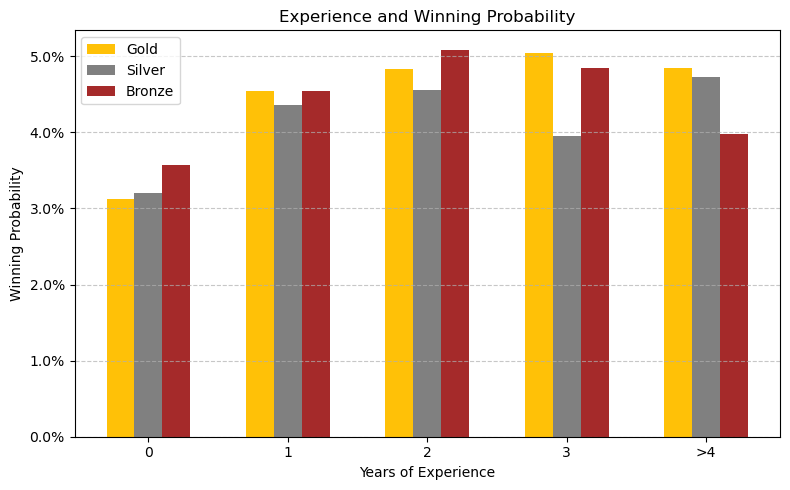

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Parameters
num_rows, num_cols = medal_tensor.shape
x = np.arange(num_rows)  # x-coordinates for each group
bar_width = 0.2         # Width of each bar
offsets = np.linspace(-bar_width, bar_width, num_cols)  # Offsets for side-by-side bars

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x + offsets[0], medal_tensor[:, 0], width=bar_width, label=f'Gold', color='#ffc107')
ax.bar(x + offsets[1], medal_tensor[:, 1], width=bar_width, label=f'Silver', color='grey')
ax.bar(x + offsets[2], medal_tensor[:, 2], width=bar_width, label=f'Bronze', color='brown')

# Customizing the plot
ax.set_xticks(x)
ax.set_xticklabels([f'{i}' for i in range(num_rows-1)] + ['>4'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Winning Probability')
ax.set_xlabel('Years of Experience')
ax.set_title('Experience and Winning Probability')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [67]:
pyro.clear_param_store()
pyro.get_param_store().load("trained_model_params_long.pth")
# print all pyro parameters
for name in pyro.get_param_store().get_all_param_names():
    print(name, pyro.param(name))

/Users/setthakorntanom/miniconda3/envs/py312/lib/python3.12/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(in

phi_alpha tensor(1.6422, grad_fn=<AddBackward0>)
phi_beta tensor(52.4426, grad_fn=<AddBackward0>)
rho_alpha tensor(1.5423, grad_fn=<AddBackward0>)
rho_beta tensor(69.9839, grad_fn=<AddBackward0>)
alpha_loc tensor([-0.1492, -0.1324, -0.1293, -0.1391, -0.1242, -0.1882, -0.2083, -0.1596,
        -0.1874,  0.0500, -0.1484, -0.1734, -0.2299,  0.1739,  0.0858, -0.0933,
        -0.1682, -0.1934, -0.2148, -0.2129,  0.2094, -0.2125, -0.2104, -0.2186,
        -0.2200, -0.1682,  0.0084, -0.1755, -0.2538, -0.1956,  0.1889, -0.1712,
        -0.1683,  0.1312, -0.2390, -0.2571, -0.1705,  0.2830, -0.2396, -0.2113,
        -0.1400, -0.1394,  0.1851, -0.1857, -0.2172, -0.1969, -0.2167, -0.1081,
        -0.1949, -0.1992, -0.1512, -0.0497, -0.2242,  0.0932, -0.1732, -0.0352,
         0.3059, -0.1866, -0.1611, -0.1790, -0.1616, -0.1287, -0.1421, -0.1807,
        -0.2232,  0.2417, -0.1175, -0.1157, -0.1195, -0.2105,  0.0736,  0.3708,
         0.0420, -0.2054, -0.1603, -0.2287,  0.2510, -0.1848, -0.1172, -0.

Text(0.5, 0.98, 'Posterior Distribution of Trained Parameters')

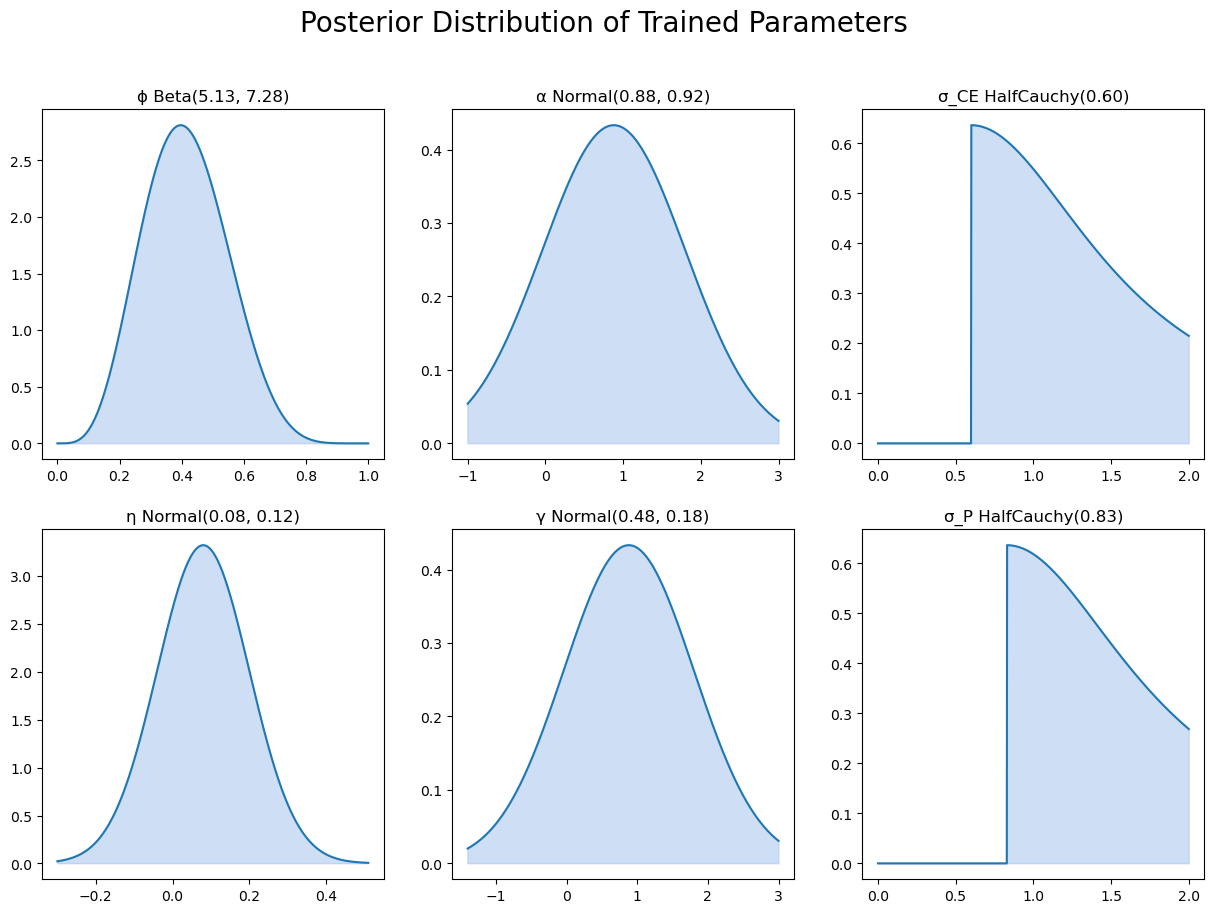

In [118]:
import scipy.stats as stats
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("grad", ["lightblue", "blue"])
# Plot posterior distribution of 6 variables in a 2x3 grid
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()
# Plot1
x = np.linspace(0,1,1000)
phi_alpha= 5.13
phi_beta = 7.28
y = stats.beta.pdf(x, phi_alpha, phi_beta)
axs[0].fill_between(x, 0, y, color='blue', alpha=0.1)  # Light shading
axs[0].fill_between(x, 0, y, color=cmap(x), alpha=0.4)  # Gradient shading
axs[0].plot(x, y)
axs[0].set_title(f"ϕ Beta(5.13, 7.28)")

# Plot2
x = np.linspace(-1,3,1000)
alpha_mean= 0.88
alpha_std = 0.921
y = stats.norm.pdf(x, alpha_mean, alpha_std)
axs[1].fill_between(x, 0, y, color='blue', alpha=0.1)  # Light shading
axs[1].fill_between(x, 0, y, color=cmap(x), alpha=0.4)  # Gradient shading
axs[1].plot(x, y)
axs[1].set_title(f"α Normal(0.88, 0.92)")

# Plot3
x = np.linspace(0,2,1000)
sig2CE_scale = 0.60
y = stats.halfcauchy.pdf(x, sig2CE_scale)
axs[2].fill_between(x, 0, y, color='blue', alpha=0.1)  # Light shading
axs[2].fill_between(x, 0, y, color=cmap(x), alpha=0.4)  # Gradient shading
axs[2].plot(x, y)
axs[2].set_title(f"σ_CE HalfCauchy(0.60)")

# Plot4
x = np.linspace(-0.3,0.51,1000)
eta_mean= 0.08
eta_std = 0.12
y = stats.norm.pdf(x, eta_mean, eta_std)
axs[3].fill_between(x, 0, y, color='blue', alpha=0.1)  # Light shading
axs[3].fill_between(x, 0, y, color=cmap(x), alpha=0.4)  # Gradient shading
axs[3].plot(x, y)
axs[3].set_title(f"η Normal(0.08, 0.12)")

# Plot5
x = np.linspace(-1.4,3,1000)
gamma_mean= 0.48
gamma_std = 0.18
y = stats.norm.pdf(x, alpha_mean, alpha_std)
axs[4].fill_between(x, 0, y, color='blue', alpha=0.1)  # Light shading
axs[4].fill_between(x, 0, y, color=cmap(x), alpha=0.4)  # Gradient shading
axs[4].plot(x, y)
axs[4].set_title(f"γ Normal(0.48, 0.18)")

# Plot6
x = np.linspace(0,2,1000)
sig2CE_scale = 0.83
y = stats.halfcauchy.pdf(x, sig2CE_scale)
axs[5].fill_between(x, 0, y, color='blue', alpha=0.1)  # Light shading
axs[5].fill_between(x, 0, y, color=cmap(x), alpha=0.4)  # Gradient shading
axs[5].plot(x, y)
axs[5].set_title(f"σ_P HalfCauchy(0.83)")

#title
fig.suptitle("Posterior Distribution of Trained Parameters", fontsize=20)
